In [12]:
import os
from glob import glob

import numpy as np
import pandas as pd
import scipy.io
import mne

from tqdm import tqdm

In [13]:
TDC = "CleanData_TDC"
IDD = "CleanData_IDD"

In [14]:
print("Current Working Directory:")
print(os.getcwd())

print("\nContents of TDC:")
print(os.listdir(TDC))

print("\nContents of IDD:")
print(os.listdir(IDD))

Current Working Directory:
c:\Users\Asus\BCI-EEG-Signal-Classification

Contents of TDC:
['Music', 'Rest', '_DS_Store']

Contents of IDD:
['Music', 'Rest', '_DS_Store']


In [15]:
tdc_music = sorted(glob(os.path.join(TDC, "Music", "*.mat")))
tdc_rest  = sorted(glob(os.path.join(TDC, "Rest", "*.mat")))

idd_music = sorted(glob(os.path.join(IDD, "Music", "*.mat")))
idd_rest  = sorted(glob(os.path.join(IDD, "Rest", "*.mat")))

print("TDC Music:", len(tdc_music))
print("TDC Rest :", len(tdc_rest))
print("IDD Music:", len(idd_music))
print("IDD Rest :", len(idd_rest))

TDC Music: 7
TDC Rest : 7
IDD Music: 7
IDD Rest : 8


In [16]:
print("First TDC Music file:")
print(tdc_music[0])

First TDC Music file:
CleanData_TDC\Music\CGS01_Music_CD.mat


In [17]:
data = scipy.io.loadmat(tdc_music[0])

In [18]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'clean_data'])


In [19]:
eeg = data["clean_data"]

print(eeg.shape)

(14, 15360)


In [30]:
import mne

sampling_freq = 128

ch_names = [
    'AF3','F7','F3','FC5',
    'T7','P7','O1','O2',
    'P8','T8','FC6','F4',
    'F8','AF4'
]

ch_types = ['eeg'] * len(ch_names)

def convert_mat_to_epochs(eeg):

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sampling_freq,
        ch_types=ch_types
    )

    info.set_montage("standard_1020")

    raw = mne.io.RawArray(eeg, info, verbose=False)

    raw.set_eeg_reference(verbose=False)

    raw.filter(
        l_freq=1,
        h_freq=30,
        verbose=False
    )

    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=4,
        overlap=0,
        preload=True,
        verbose=False
    )

    return epochs.get_data()

In [31]:
raw = mne.io.RawArray(eeg, info)

raw

Creating RawArray with float64 data, n_channels=14, n_times=15360
    Range : 0 ... 15359 =      0.000 ...   119.992 secs
Ready.


<RawArray | 14 x 15360 (120.0 s), ~1.7 MiB, data loaded>

Using matplotlib as 2D backend.


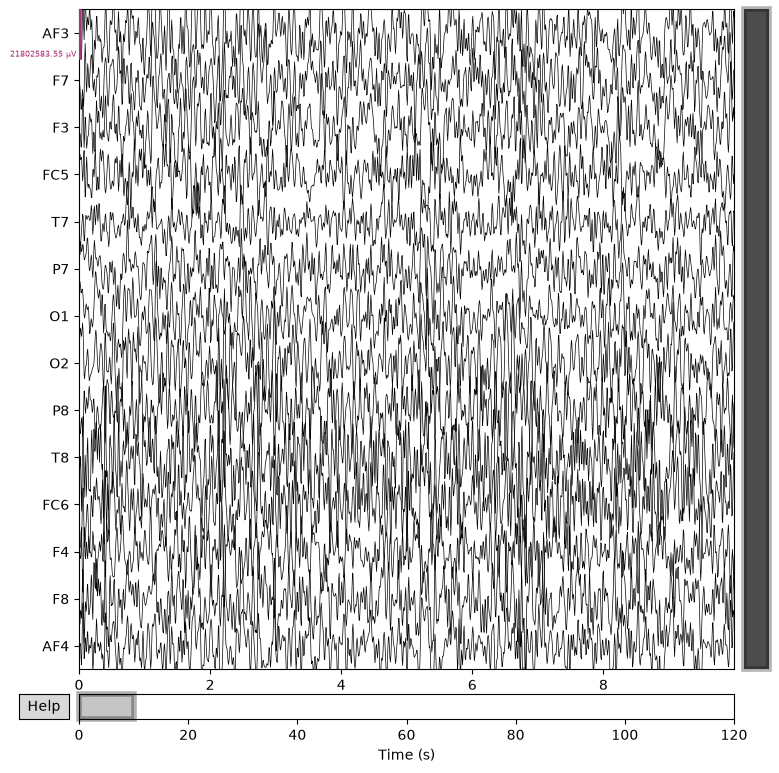

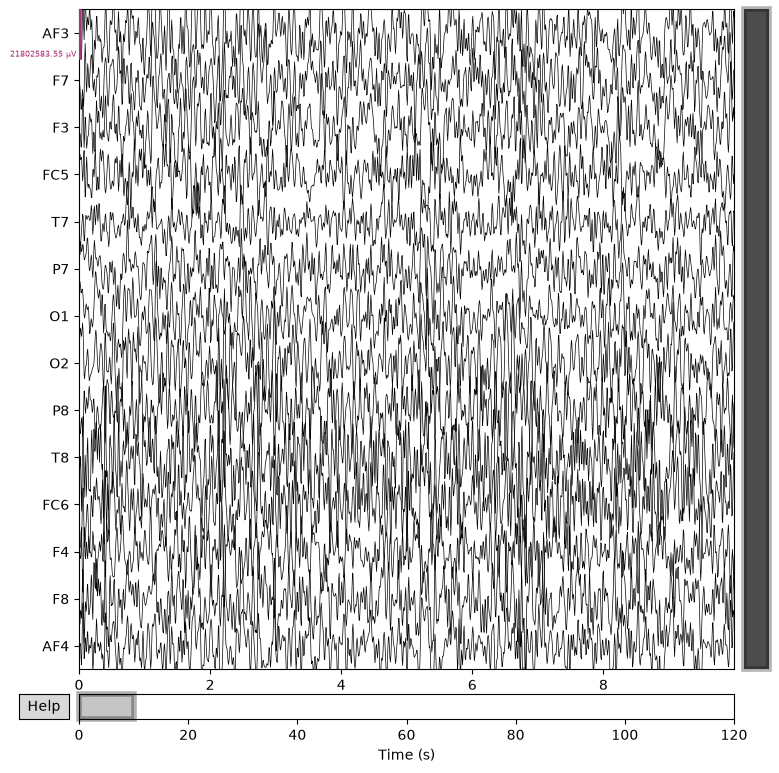

In [23]:
raw.plot(duration=10, scalings='auto')

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Asus\BCI-EEG-Signal-Classification\env\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


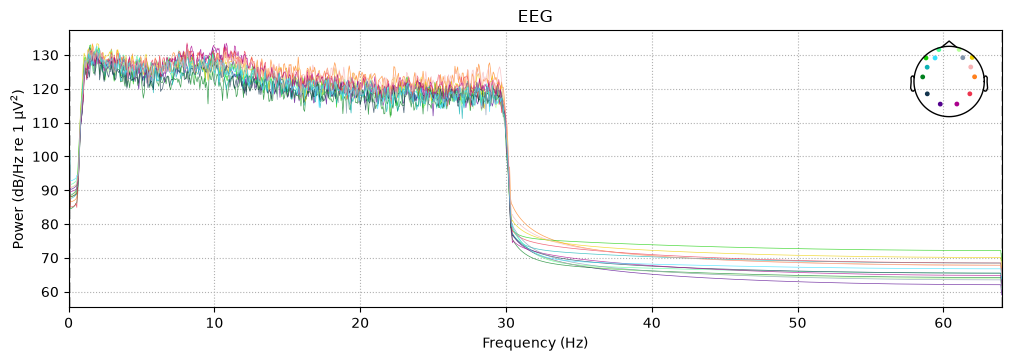

In [24]:
raw.compute_psd().plot()

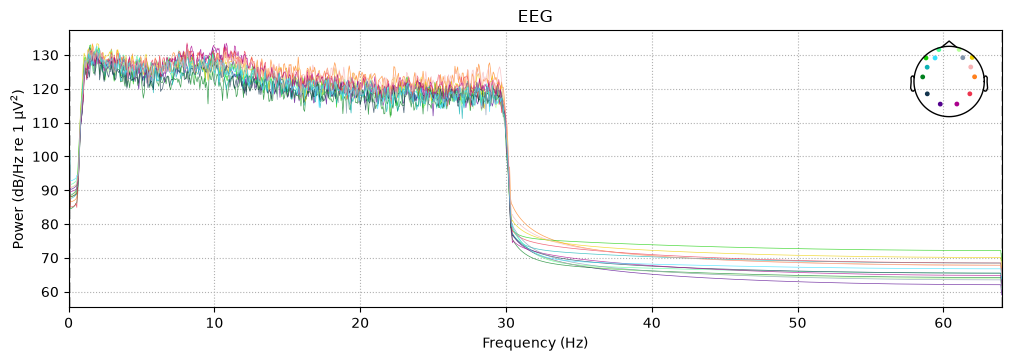

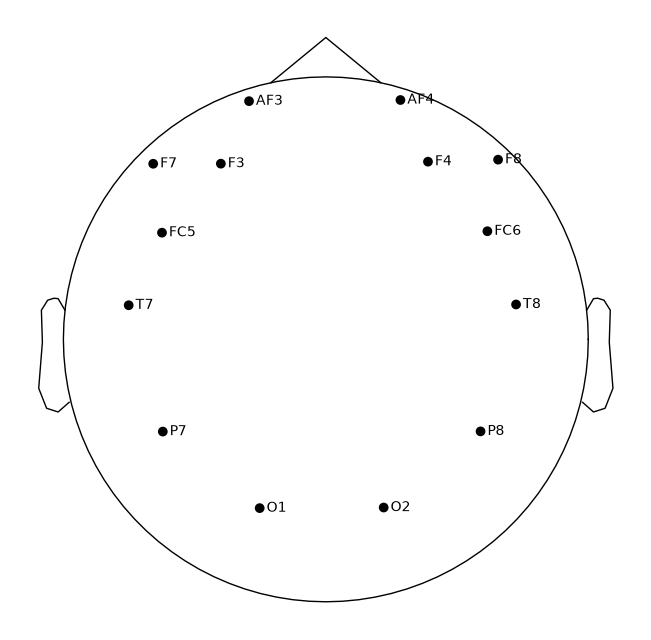

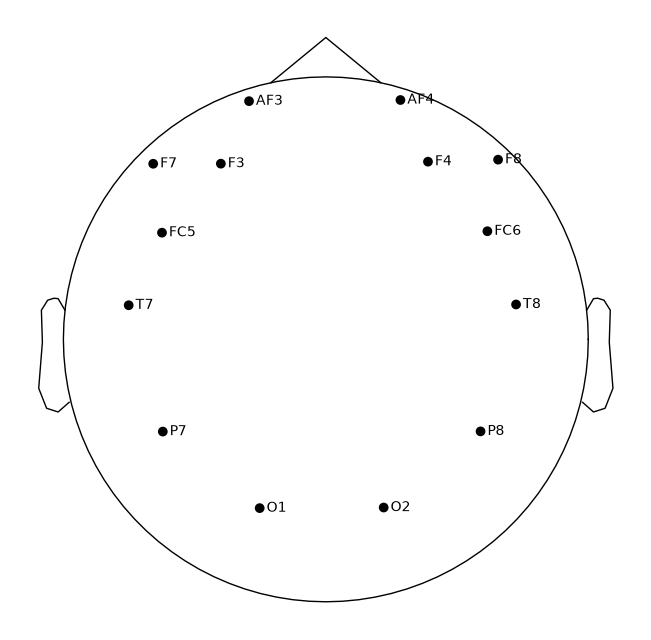

In [25]:
raw.plot_sensors(show_names=True)

In [26]:
epochs = mne.make_fixed_length_epochs(
    raw,
    duration=4,
    overlap=0,
    preload=True
)

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 512 original time points ...
0 bad epochs dropped


In [28]:
epochs_data = epochs.get_data()

print(epochs_data.shape)

(30, 14, 512)


In [32]:
epochs = convert_mat_to_epochs(eeg)

print(epochs.shape)

(30, 14, 512)


In [33]:
idd_subjects = []

for file in glob(IDD + "/Rest/*.mat"):
    eeg = scipy.io.loadmat(file)["clean_data"]
    epochs = convert_mat_to_epochs(eeg)
    idd_subjects.append(epochs)

print("IDD Subjects:", len(idd_subjects))

IDD Subjects: 8


In [34]:
tdc_subjects = []

for file in glob(TDC + "/Rest/*.mat"):
    eeg = scipy.io.loadmat(file)["clean_data"]
    epochs = convert_mat_to_epochs(eeg)
    tdc_subjects.append(epochs)

print("TDC Subjects:", len(tdc_subjects))

TDC Subjects: 7


In [35]:
print(len(idd_subjects))
print(len(tdc_subjects))

8
7


In [36]:
print(idd_subjects[0].shape)
print(tdc_subjects[0].shape)

(30, 14, 512)
(30, 14, 512)


In [60]:
import numpy as np
import torch

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from torch.utils.data import TensorDataset, DataLoader

In [43]:
class StandardScaler3D(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        self.scaler.fit(X.reshape(-1, X.shape[2]))
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(
            X.reshape(-1, X.shape[2])
        )
        return X_scaled.reshape(X.shape)

In [44]:
data_list = []
label_list = []
group_list = []

subject_id = 0

# IDD = label 1
for subject in idd_subjects:

    data_list.append(subject)

    label_list.append(
        np.ones(subject.shape[0], dtype=int)
    )

    group_list.append(
        np.full(subject.shape[0], subject_id)
    )

    subject_id += 1


# TDC = label 0
for subject in tdc_subjects:

    data_list.append(subject)

    label_list.append(
        np.zeros(subject.shape[0], dtype=int)
    )

    group_list.append(
        np.full(subject.shape[0], subject_id)
    )

    subject_id += 1

In [45]:
data_array = np.concatenate(data_list)

label_array = np.concatenate(label_list)

group_array = np.concatenate(group_list)

In [46]:
print(data_array.shape)
print(label_array.shape)
print(group_array.shape)

(450, 14, 512)
(450,)
(450,)


In [47]:
gkf = GroupKFold(n_splits=5)

In [48]:
for train_idx, val_idx in gkf.split(
    data_array,
    label_array,
    groups=group_array
):

    train_features = data_array[train_idx]
    train_labels = label_array[train_idx]

    val_features = data_array[val_idx]
    val_labels = label_array[val_idx]

    break

In [49]:
scaler = StandardScaler3D()

train_features = scaler.fit_transform(train_features)

val_features = scaler.transform(val_features)

In [50]:
print(train_features.shape)

(360, 14, 512)


In [51]:
train_features = np.moveaxis(train_features, 1, 2)
val_features = np.moveaxis(val_features, 1, 2)

In [52]:
train_features = torch.tensor(train_features, dtype=torch.float32)

val_features = torch.tensor(val_features, dtype=torch.float32)

train_labels = torch.tensor(train_labels, dtype=torch.long)

val_labels = torch.tensor(val_labels, dtype=torch.long)

In [53]:
print(len(train_features), len(train_labels))

print(len(val_features), len(val_labels))

print(train_features.shape)

print(val_features.shape)

360 360
90 90
torch.Size([360, 512, 14])
torch.Size([90, 512, 14])


In [54]:
train_dataset = TensorDataset(
    train_features,
    train_labels
)

val_dataset = TensorDataset(
    val_features,
    val_labels
)

In [55]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

Create Lightning Model

In [67]:
import torch
import torch.nn as nn
import torchmetrics
import pytorch_lightning as pl

from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl


In [98]:
class ChronoModel(pl.LightningModule):

    def __init__(self):
        super().__init__()

        # Create ChronoNet model
        self.model = ChronoNet()

        # Hyperparameters
        self.lr = 1e-3
        self.bs = 32
        self.worker = 2

        # Metrics
        self.acc = torchmetrics.Accuracy(task="binary")

        # Loss Function
        self.criterion = nn.BCEWithLogitsLoss()

In [99]:
model = ChronoModel()

In [70]:
def forward(self, x):
    return self.model(x)

In [71]:
def configure_optimizers(self):
    return torch.optim.Adam(
        self.parameters(),
        lr=self.lr
    )

In [97]:
def train_dataloader(self):

    dataset = TensorDataset(
        train_features,
        train_labels
    )

    loader = DataLoader(
        dataset,
        batch_size=self.bs,
        shuffle=True,
        num_workers=self.worker
    )

    return loader

In [75]:
def training_step(self, batch, batch_idx):

    signal, label = batch

    output = self(signal.float()).flatten()

    loss = self.criterion(
        output,
        label.float()
    )

    acc = self.acc(
        torch.sigmoid(output),
        label.long()
    )

    self.log("train_loss", loss, prog_bar=True)
    self.log("train_acc", acc, prog_bar=True)

    return loss

In [76]:
def on_train_epoch_end(self):

    print(f"Finished Epoch {self.current_epoch}")

In [77]:
def val_dataloader(self):

        dataset = TensorDataset(
            val_features,
            val_labels
        )

        loader = DataLoader(
            dataset,
            batch_size=self.bs,
            shuffle=False,
            num_workers=self.worker
        )

        return loader

In [78]:
def validation_step(self, batch, batch_idx):

        signal, label = batch

        output = self(signal.float()).flatten()

        loss = self.criterion(
            output,
            label.float()
        )

        acc = self.acc(
            torch.sigmoid(output),
            label.long()
        )

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

        return loss

In [80]:
def on_validation_epoch_end(self):

        print(f"Validation finished for Epoch {self.current_epoch}")

In [86]:
from pytorch_lightning import Trainer
trainer = Trainer(
    max_epochs=50,
    accelerator="auto",
    devices=1,
    log_every_n_steps=1
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [89]:
class ChronoNet(nn.Module):
    ...

In [90]:
print(ChronoNet)

<class '__main__.ChronoNet'>


In [101]:
model = ChronoModel()

Plot an EEG Signal


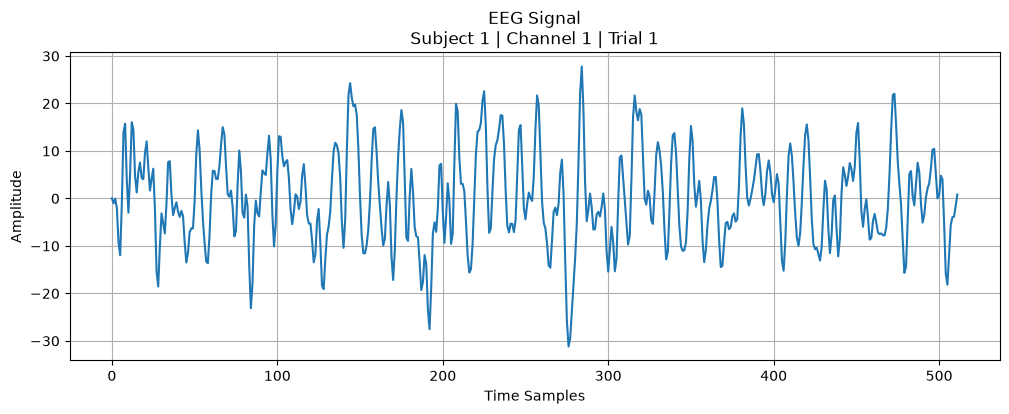

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(epochs_data[0,0,:])
plt.title("EEG Signal\nSubject 1 | Channel 1 | Trial 1")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

Plot Multiple EEG Channels

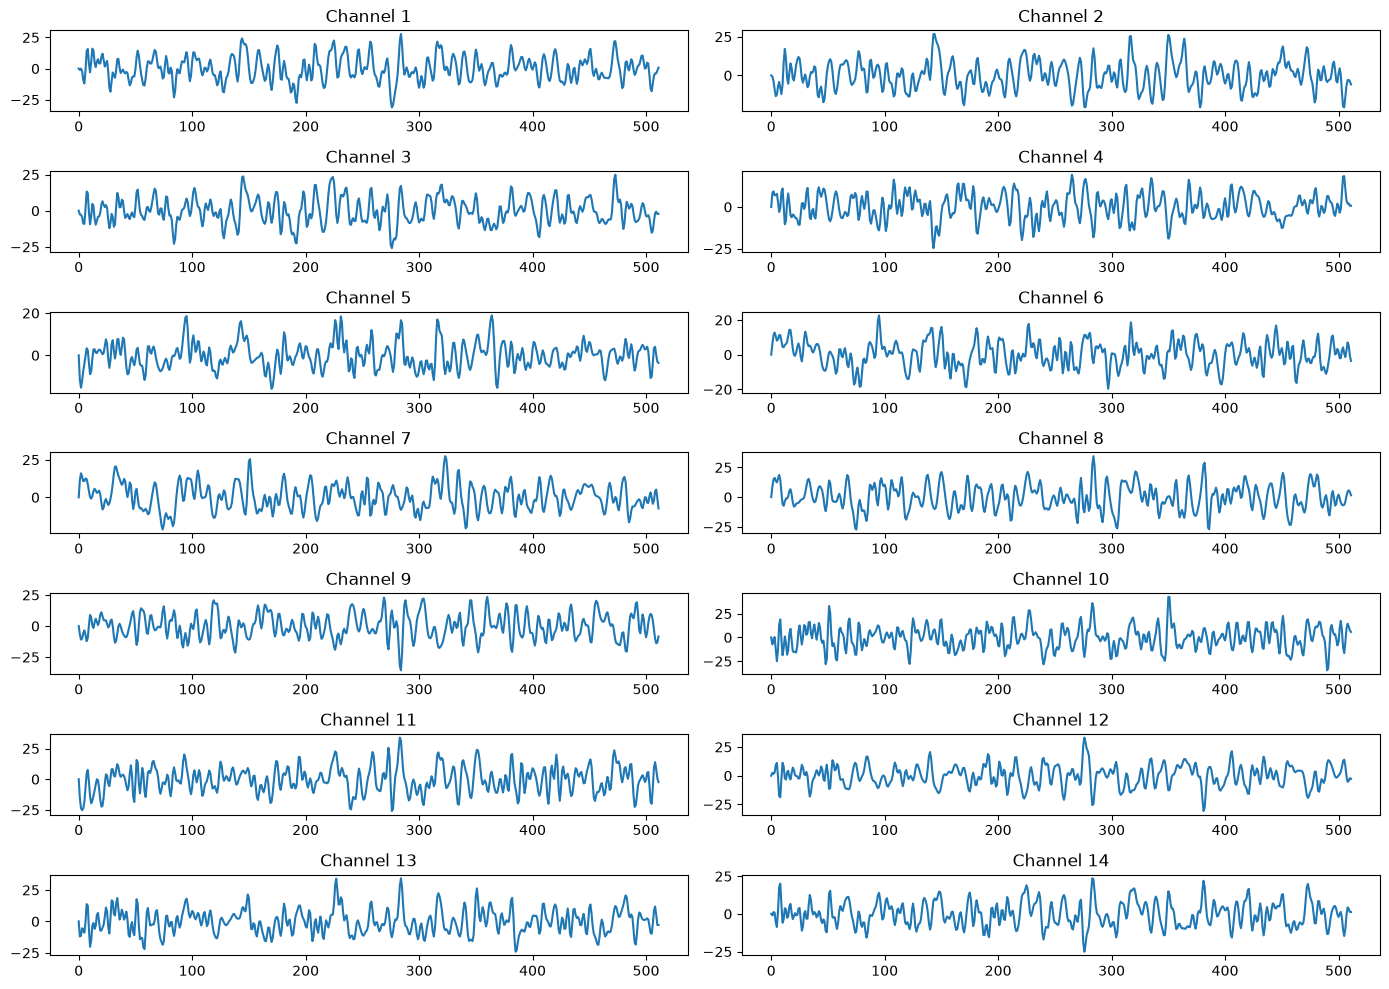

In [103]:
fig, ax = plt.subplots(7,2,figsize=(14,10))

for i in range(14):
    ax[i//2,i%2].plot(epochs_data[0,i,:])
    ax[i//2,i%2].set_title(f"Channel {i+1}")

plt.tight_layout()
plt.show()

Heatmap of One EEG Trial

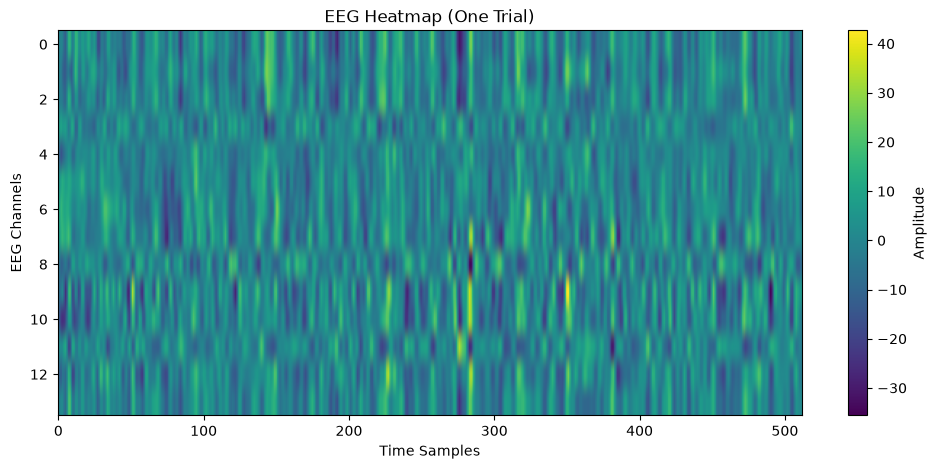

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.imshow(
    epochs_data[0],
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label="Amplitude")
plt.xlabel("Time Samples")
plt.ylabel("EEG Channels")
plt.title("EEG Heatmap (One Trial)")

plt.show()

Average EEG Signal Across Channels

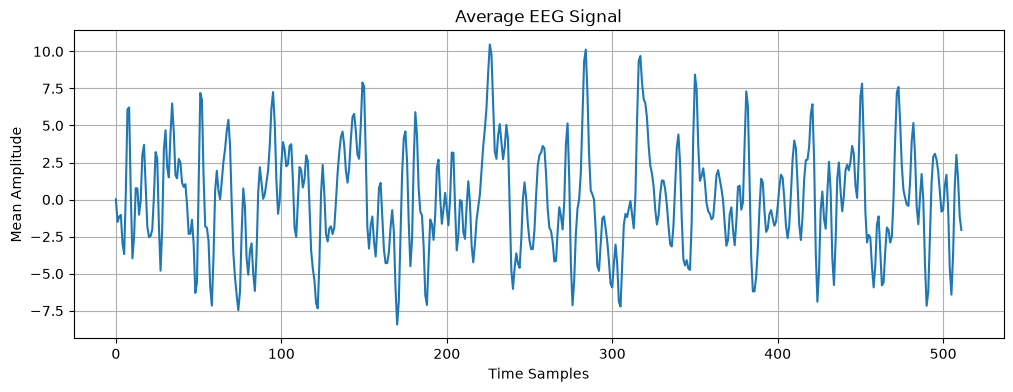

In [105]:
mean_signal = epochs_data[0].mean(axis=0)

plt.figure(figsize=(12,4))
plt.plot(mean_signal)

plt.title("Average EEG Signal")
plt.xlabel("Time Samples")
plt.ylabel("Mean Amplitude")

plt.grid(True)
plt.show()

Power Spectral Density (PSD)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Asus\BCI-EEG-Signal-Classification\env\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


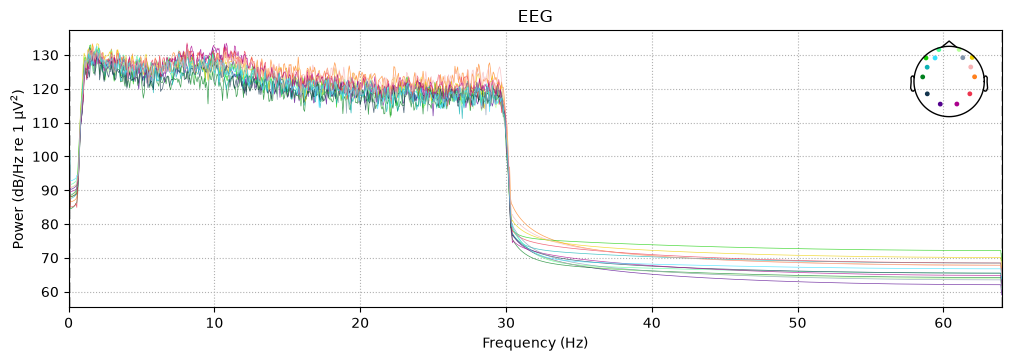

In [106]:
raw.plot_psd()

Frequency Spectrum (FFT)

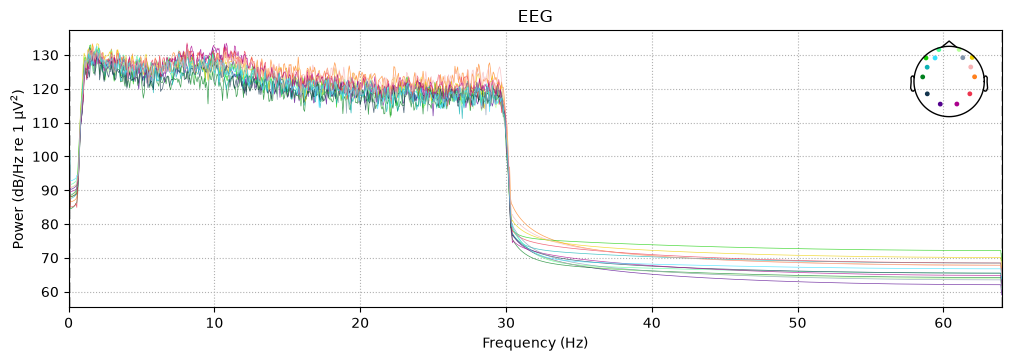

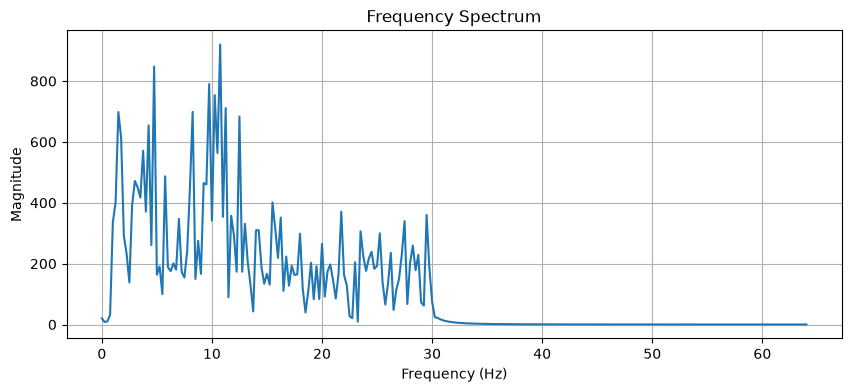

In [107]:
signal = epochs_data[0,0,:]

fft = np.fft.rfft(signal)

freq = np.fft.rfftfreq(len(signal),1/128)

plt.figure(figsize=(10,4))

plt.plot(freq,np.abs(fft))

plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

Music vs Rest Comparison

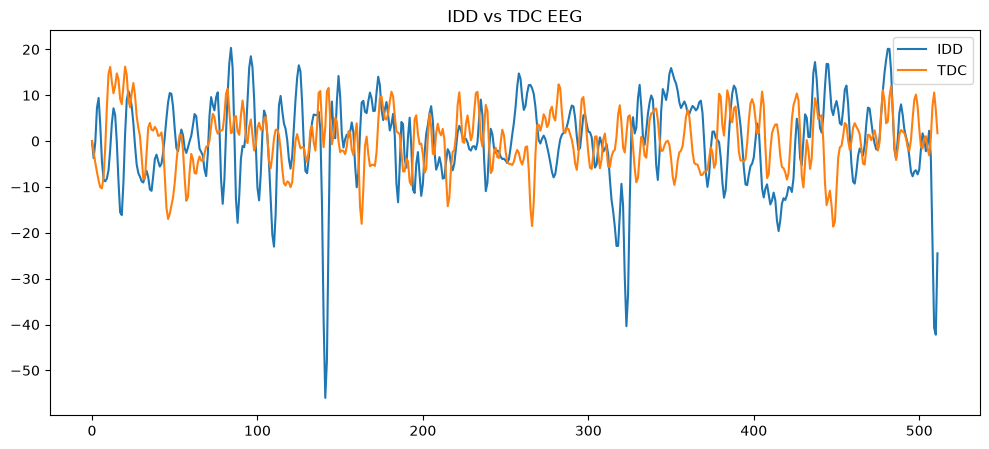

In [108]:
music = idd_subjects[0][0,0,:]
rest = tdc_subjects[0][0,0,:]

plt.figure(figsize=(12,5))

plt.plot(music,label="IDD")
plt.plot(rest,label="TDC")

plt.legend()

plt.title("IDD vs TDC EEG")

plt.show()

Spectrogram

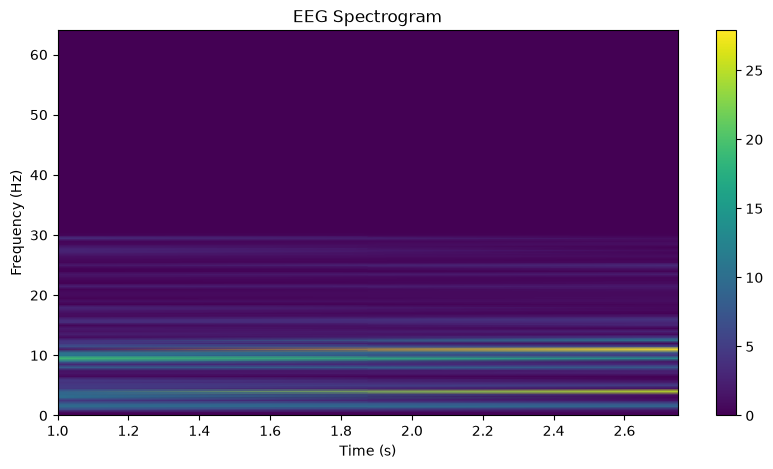

In [109]:
from scipy import signal

f,t,Sxx = signal.spectrogram(
    epochs_data[0,0,:],
    fs=128
)

plt.figure(figsize=(10,5))

plt.pcolormesh(t,f,Sxx,shading='gouraud')

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("EEG Spectrogram")

plt.colorbar()

plt.show()

Brain Activity Heatmap

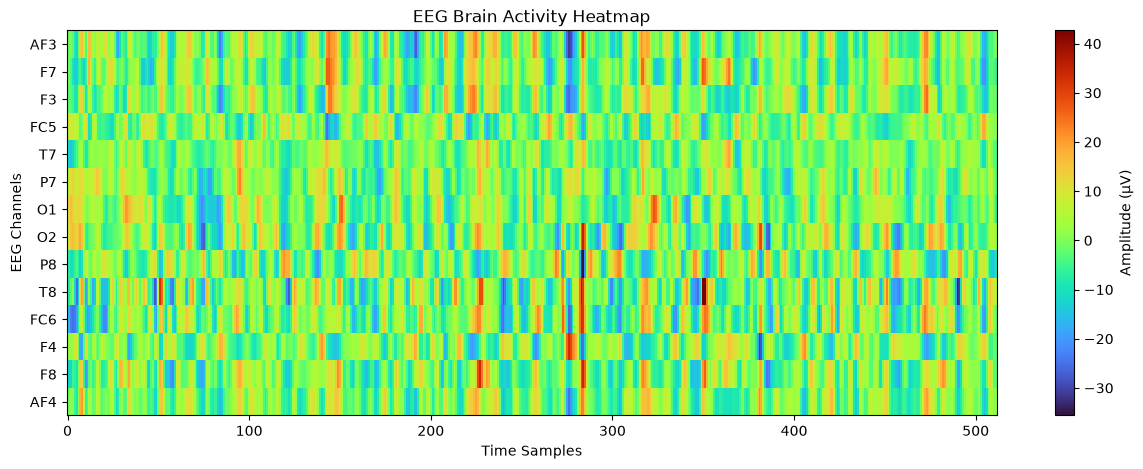

In [110]:
plt.figure(figsize=(15,5))

plt.imshow(
    epochs_data[0],
    aspect='auto',
    cmap='turbo',
    interpolation='nearest'
)

plt.colorbar(label='Amplitude (µV)')

plt.yticks(range(14), raw.ch_names)

plt.xlabel("Time Samples")
plt.ylabel("EEG Channels")
plt.title("EEG Brain Activity Heatmap")

plt.show()

Alpha/Beta Frequency Spectrum

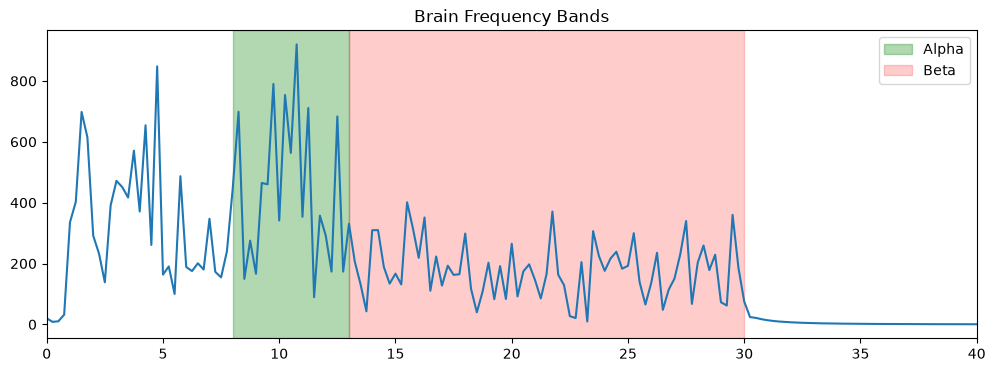

In [111]:
signal = epochs_data[0,0,:]

fft = np.fft.rfft(signal)

freq = np.fft.rfftfreq(len(signal),1/128)

plt.figure(figsize=(12,4))

plt.plot(freq,np.abs(fft))

plt.xlim(0,40)

plt.axvspan(8,13,color='green',alpha=.3,label='Alpha')

plt.axvspan(13,30,color='red',alpha=.2,label='Beta')

plt.legend()

plt.title("Brain Frequency Bands")

plt.show()

Average Brain Signal (IDD vs TDC)

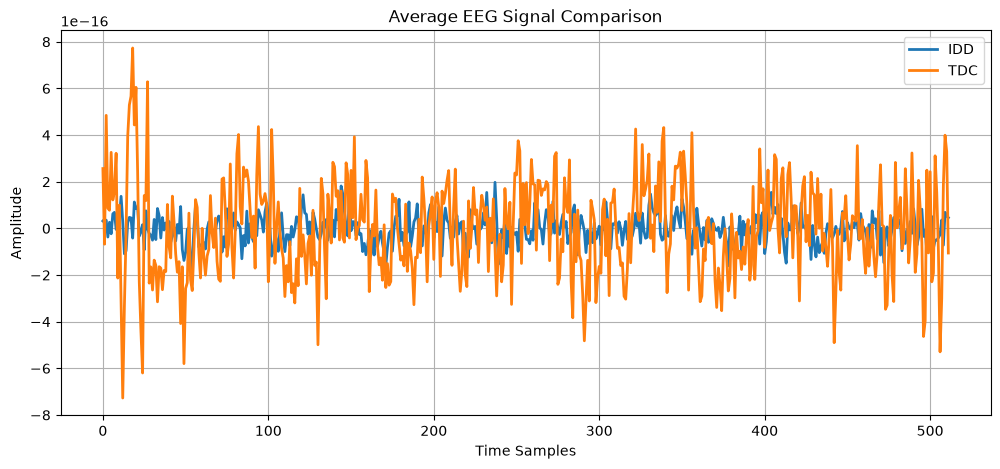

In [112]:
idd_mean = np.mean(data_array[label_array == 1], axis=(0, 1))
tdc_mean = np.mean(data_array[label_array == 0], axis=(0, 1))

plt.figure(figsize=(12,5))

plt.plot(idd_mean, label='IDD', linewidth=2)
plt.plot(tdc_mean, label='TDC', linewidth=2)

plt.title("Average EEG Signal Comparison")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()